<a href="https://colab.research.google.com/github/shivakumar3176/storm-nowcasting-capstone/blob/main/SEVIRCapstoneFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install h5py matplotlib numpy pytorch-msssim

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import urllib.request
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ssim as ssim_metric

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
url = 'https://sevir.s3.amazonaws.com/data/vil/2018/SEVIR_VIL_STORMEVENTS_2018_0101_0630.h5'
file_name = 'sevir_sample_vil.h5'

if not os.path.exists(file_name):
    print("Downloading SEVIR sample (approx 1.5 GB)... this might take a few minutes.")
    try:
        urllib.request.urlretrieve(url, file_name)
        print("Download complete!")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print("File already exists.")

File already exists.


In [4]:
with h5py.File(file_name, 'r') as hf:
    print("Keys in the HDF5 file:", list(hf.keys()))
    event_id = hf['id'][0]
    radar_sequence = hf['vil'][0]
    print(f"Event ID: {event_id.decode('utf-8')}")
    print(f"Radar sequence shape: {radar_sequence.shape}")  # (384, 384, 49)

Keys in the HDF5 file: ['id', 'vil']
Event ID: S728503
Radar sequence shape: (384, 384, 49)


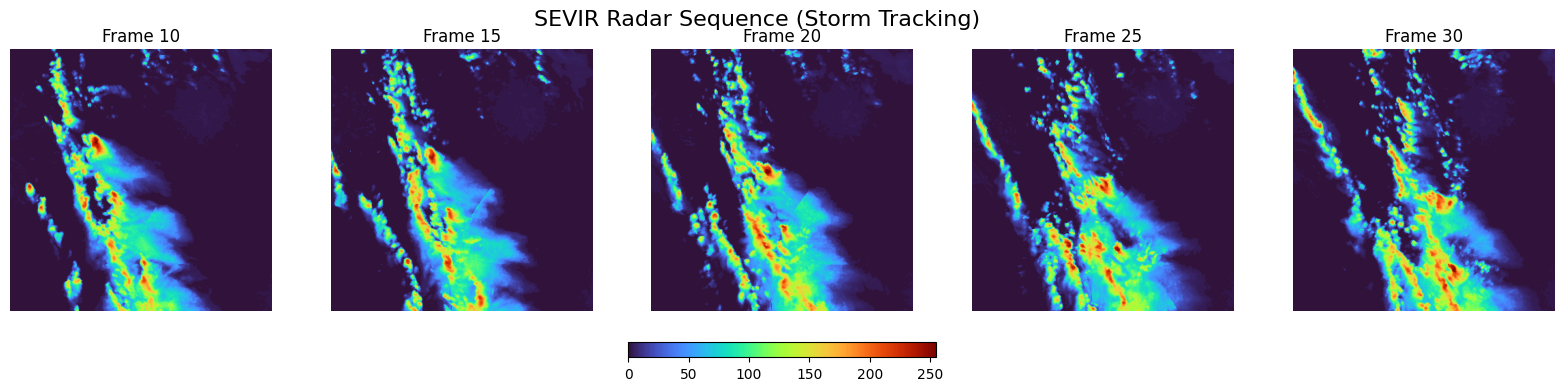

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
frames_to_plot = [10, 15, 20, 25, 30]

with h5py.File(file_name, 'r') as hf:
    radar_sequence = hf['vil'][0]
    for i, frame_idx in enumerate(frames_to_plot):
        ax = axes[i]
        img = ax.imshow(radar_sequence[:, :, frame_idx], cmap='turbo', vmin=0, vmax=255)
        ax.set_title(f"Frame {frame_idx}")
        ax.axis('off')

plt.colorbar(img, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
plt.suptitle("SEVIR Radar Sequence (Storm Tracking)", fontsize=16)
plt.show()

In [6]:
class SEVIRDataset(Dataset):
    """
    Unified dataset for both U-Net (spatial) and ConvLSTM (sequential) models.

    Returns:
        x_spatial : (num_input, H, W)        — for U-Net
        x_seq     : (num_input, 1, H, W)     — for ConvLSTM
        y         : (num_target, 1, H, W)    — ground truth future frames
        max_vil   : scalar float             — max VIL in target, used for severity split
    """
    def __init__(self, h5_file, num_input=5, num_target=5, n_events=100, split='train', seed=42):
        with h5py.File(h5_file, 'r') as hf:
            self.data = hf['vil'][:n_events].astype(np.float32) / 255.0  # (N, 384, 384, 49)

        self.num_input  = num_input
        self.num_target = num_target

        # 80/20 split
        n = len(self.data)
        rng = np.random.default_rng(seed)
        idx = rng.permutation(n)
        cut = int(0.8 * n)
        self.indices = idx[:cut] if split == 'train' else idx[cut:]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        event = self.data[self.indices[i]]               # (384, 384, 49)

        # Centre-crop to 128×128
        cx, cy = event.shape[0] // 2, event.shape[1] // 2
        event = event[cx-64:cx+64, cy-64:cy+64, :]       # (128, 128, 49)

        # Randomise start index so the model sees varied temporal windows
        max_start = 49 - self.num_input - self.num_target
        start = np.random.randint(0, max_start + 1)

        x = event[:, :, start : start + self.num_input]                              # (H, W, T_in)
        y = event[:, :, start + self.num_input : start + self.num_input + self.num_target]  # (H, W, T_out)

        # U-Net input: (T_in, H, W)
        x_spatial = np.transpose(x, (2, 0, 1)).copy()

        # ConvLSTM input: (T_in, 1, H, W)
        x_seq = np.expand_dims(x_spatial, axis=1).copy()

        # Target: (T_out, 1, H, W)
        y_out = np.expand_dims(np.transpose(y, (2, 0, 1)), axis=1).copy()

        max_vil = float(y_out.max())

        return (
            torch.tensor(x_spatial),
            torch.tensor(x_seq),
            torch.tensor(y_out),
            max_vil
        )

# Build loaders
NUM_INPUT  = 5
NUM_TARGET = 5   # predict 5 future frames (~25 min window)

train_dataset = SEVIRDataset(file_name, NUM_INPUT, NUM_TARGET, n_events=100, split='train')
test_dataset  = SEVIRDataset(file_name, NUM_INPUT, NUM_TARGET, n_events=100, split='test')

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

x_sp, x_sq, y_t, mv = next(iter(train_loader))
print(f"U-Net input shape    : {x_sp.shape}")   # (B, T_in, H, W)
print(f"ConvLSTM input shape : {x_sq.shape}")   # (B, T_in, 1, H, W)
print(f"Target shape         : {y_t.shape}")    # (B, T_out, 1, H, W)
print(f"Max VIL sample       : {mv}")

U-Net input shape    : torch.Size([4, 5, 128, 128])
ConvLSTM input shape : torch.Size([4, 5, 1, 128, 128])
Target shape         : torch.Size([4, 5, 1, 128, 128])
Max VIL sample       : tensor([0.7176, 0.9961, 0.9961, 0.8431], dtype=torch.float64)


In [7]:
from pytorch_msssim import ssim

class CombinedLoss(nn.Module):
    """
    Loss = MSE + alpha * (1 - SSIM)

    MSE penalises pixel-level error.
    SSIM penalises structural/perceptual degradation.
    alpha=0.8 matches the value cited in the GDD.
    """
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        # pred/target shape: (B, C, H, W) — SSIM expects this
        mse_loss  = self.mse(pred, target)
        # data_range=1.0 because we normalised VIL to [0,1]
        ssim_loss = 1.0 - ssim(pred, target, data_range=1.0, size_average=True)
        return mse_loss + self.alpha * ssim_loss, mse_loss, ssim_loss

criterion = CombinedLoss(alpha=0.8)
print("Combined MSE + SSIM loss ready.")

Combined MSE + SSIM loss ready.


In [8]:
class SimpleUNet(nn.Module):
    """
    Encoder-decoder U-Net.
    Input : (B, T_in, H, W)  — T_in stacked radar frames as channels
    Output: (B, T_out, 1, H, W)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.enc1       = self._block(in_channels, 32)
        self.enc2       = self._block(32, 64)
        self.bottleneck = self._block(64, 128)
        self.upconv2    = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2       = self._block(128, 64)
        self.upconv1    = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1       = self._block(64, 32)
        self.out_conv   = nn.Conv2d(32, out_channels, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # x: (B, T_in, H, W) — treat time steps as channels
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        b  = self.bottleneck(F.max_pool2d(e2, 2))
        d2 = self.dec2(torch.cat([self.upconv2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.upconv1(d2), e1], dim=1))
        out = torch.sigmoid(self.out_conv(d1))          # (B, T_out, H, W)
        return out.unsqueeze(2)                          # (B, T_out, 1, H, W)

unet_model = SimpleUNet(in_channels=NUM_INPUT, out_channels=NUM_TARGET).to(device)
print(f"U-Net output shape test: {unet_model(x_sp.to(device)).shape}")

U-Net output shape test: torch.Size([4, 5, 1, 128, 128])


In [9]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        pad = kernel_size // 2
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=pad)

    def forward(self, x, state):
        h, c = state
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.split(gates, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next


class StormPredictorConvLSTM(nn.Module):
    """
    Encoder-decoder ConvLSTM.
    Encoder  : reads T_in past frames, builds hidden state
    Decoder  : autoregressively generates T_out future frames
    Input    : (B, T_in, 1, H, W)
    Output   : (B, T_out, 1, H, W)
    """
    def __init__(self, input_dim=1, hidden_dim=32, kernel_size=3, num_target=5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_target = num_target
        self.encoder_cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.decoder_cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.out_conv     = nn.Conv2d(hidden_dim, 1, 3, padding=1)

    def forward(self, x):
        # x: (B, T_in, 1, H, W)
        B, T_in, C, H, W = x.shape
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)

        # Encoder: digest past frames
        for t in range(T_in):
            h, c = self.encoder_cell(x[:, t], (h, c))

        # Decoder: generate future frames autoregressively
        outputs = []
        dec_input = x[:, -1]                 # seed with last known frame
        for _ in range(self.num_target):
            h, c = self.decoder_cell(dec_input, (h, c))
            pred = torch.sigmoid(self.out_conv(h))  # (B, 1, H, W)
            pred = pred * 1.5                        # intensity bias — prevent output collapse
            pred = pred.clamp(0, 1)                  # keep in valid range
            outputs.append(pred.unsqueeze(1))         # (B, 1, 1, H, W)
            dec_input = pred                          # feed prediction back in

        return torch.cat(outputs, dim=1)      # (B, T_out, 1, H, W)


convlstm_model = StormPredictorConvLSTM(
    input_dim=1, hidden_dim=32, kernel_size=3, num_target=NUM_TARGET
).to(device)
print(f"ConvLSTM output shape test: {convlstm_model(x_sq.to(device)).shape}")

ConvLSTM output shape test: torch.Size([4, 5, 1, 128, 128])


In [10]:
def compute_metrics(preds, targets, thresholds=(0.3, 0.7)):
    """
    preds, targets: (B, T, 1, H, W) tensors on any device
    Returns dict with CSI, POD, FAR at each threshold + mean SSIM
    """
    results = {}

    # Flatten batch and time for pixel-level stats
    p_flat = preds.reshape(-1, 1, preds.shape[-2], preds.shape[-1])
    t_flat = targets.reshape(-1, 1, targets.shape[-2], targets.shape[-1])

    for thr in thresholds:
        p_bin = (p_flat > thr).float()
        t_bin = (t_flat > thr).float()
        hits   = (p_bin * t_bin).sum().item()
        misses = ((1 - p_bin) * t_bin).sum().item()
        fas    = (p_bin * (1 - t_bin)).sum().item()
        eps    = 1e-6
        results[f'POD@{thr}'] = hits / (hits + misses + eps)
        results[f'FAR@{thr}'] = fas  / (hits + fas    + eps)
        results[f'CSI@{thr}'] = hits / (hits + misses + fas + eps)

    # SSIM on flattened frames
    with torch.no_grad():
        results['SSIM'] = ssim_metric(
            p_flat.clamp(0, 1), t_flat.clamp(0, 1),
            data_range=1.0, size_average=True
        ).item()

    return results

print("Metric function ready (CSI/POD/FAR at 0.3 and 0.7, plus SSIM).")

Metric function ready (CSI/POD/FAR at 0.3 and 0.7, plus SSIM).


In [11]:
def train_model(model, loader, optimizer, n_epochs, model_name):
    history = {'total': [], 'mse': [], 'ssim_loss': []}
    print(f"\n{'='*50}")
    print(f"Training {model_name} for {n_epochs} epochs on {device}")
    print(f"{'='*50}")

    for epoch in range(n_epochs):
        model.train()
        totals = {'total': 0, 'mse': 0, 'ssim': 0}

        for x_sp, x_sq, y, _ in loader:
            # Choose the right input format per model
            if model_name == 'U-Net':
                inp = x_sp.to(device)           # (B, T_in, H, W)
            else:
                inp = x_sq.to(device)           # (B, T_in, 1, H, W)

            tgt = y.to(device)                  # (B, T_out, 1, H, W)

            optimizer.zero_grad()
            pred = model(inp)                   # (B, T_out, 1, H, W)

            # Flatten time into batch for loss calculation
            pred_f = pred.reshape(-1, 1, pred.shape[-2], pred.shape[-1])
            tgt_f  = tgt.reshape(-1, 1, tgt.shape[-2],  tgt.shape[-1])

            loss, mse_l, ssim_l = criterion(pred_f, tgt_f)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
            optimizer.step()

            totals['total'] += loss.item()
            totals['mse']   += mse_l.item()
            totals['ssim']  += ssim_l.item()

        n = len(loader)
        history['total'].append(totals['total'] / n)
        history['mse'].append(totals['mse'] / n)
        history['ssim_loss'].append(totals['ssim'] / n)

        print(f"Epoch [{epoch+1:2d}/{n_epochs}]  "
              f"Total: {history['total'][-1]:.5f}  "
              f"MSE: {history['mse'][-1]:.5f}  "
              f"SSIM-loss: {history['ssim_loss'][-1]:.5f}")

    return history


# Train U-Net
unet_optimizer = optim.Adam(unet_model.parameters(), lr=1e-3)
unet_history   = train_model(unet_model, train_loader, unet_optimizer, n_epochs=15, model_name='U-Net')

# Train ConvLSTM
clstm_optimizer = optim.Adam(convlstm_model.parameters(), lr=1e-3)
clstm_history   = train_model(convlstm_model, train_loader, clstm_optimizer, n_epochs=15, model_name='ConvLSTM')


Training U-Net for 15 epochs on cuda
Epoch [ 1/15]  Total: 0.66627  MSE: 0.08792  SSIM-loss: 0.72294
Epoch [ 2/15]  Total: 0.44800  MSE: 0.02572  SSIM-loss: 0.52785
Epoch [ 3/15]  Total: 0.36165  MSE: 0.01904  SSIM-loss: 0.42827
Epoch [ 4/15]  Total: 0.33940  MSE: 0.01951  SSIM-loss: 0.39986
Epoch [ 5/15]  Total: 0.34001  MSE: 0.01819  SSIM-loss: 0.40228
Epoch [ 6/15]  Total: 0.32618  MSE: 0.01628  SSIM-loss: 0.38737
Epoch [ 7/15]  Total: 0.33660  MSE: 0.01942  SSIM-loss: 0.39647
Epoch [ 8/15]  Total: 0.34109  MSE: 0.01866  SSIM-loss: 0.40303
Epoch [ 9/15]  Total: 0.32622  MSE: 0.01672  SSIM-loss: 0.38688
Epoch [10/15]  Total: 0.30532  MSE: 0.01654  SSIM-loss: 0.36098
Epoch [11/15]  Total: 0.30013  MSE: 0.01482  SSIM-loss: 0.35664
Epoch [12/15]  Total: 0.30120  MSE: 0.01470  SSIM-loss: 0.35813
Epoch [13/15]  Total: 0.30182  MSE: 0.01571  SSIM-loss: 0.35764
Epoch [14/15]  Total: 0.29632  MSE: 0.01591  SSIM-loss: 0.35052
Epoch [15/15]  Total: 0.29062  MSE: 0.01344  SSIM-loss: 0.34648

T

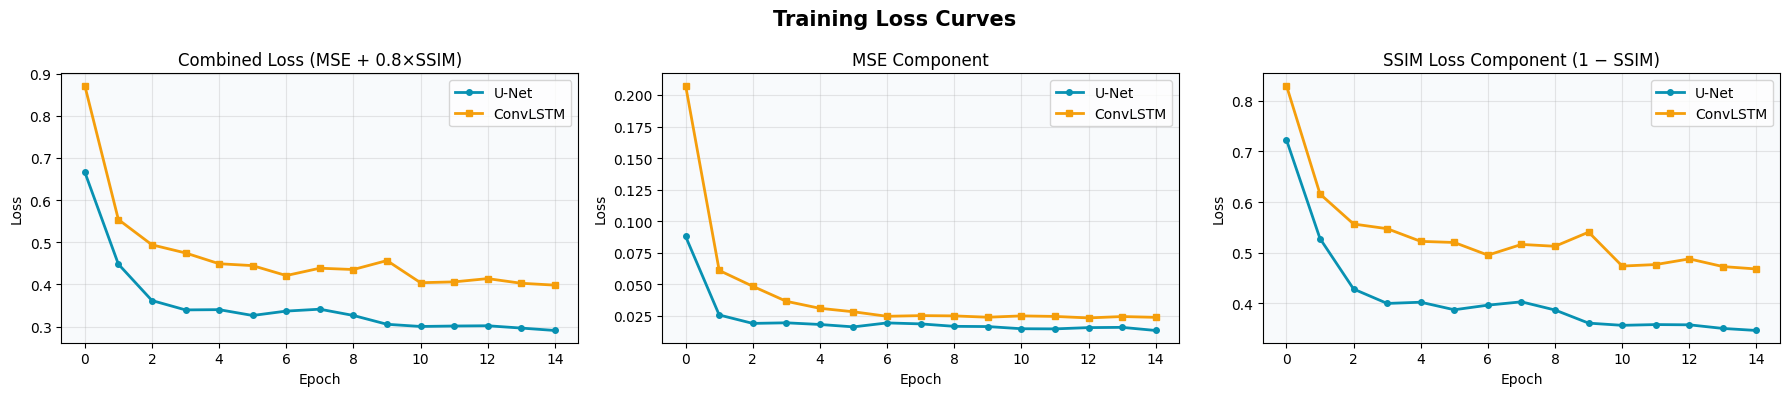

Saved: training_loss_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Training Loss Curves", fontsize=15, fontweight='bold')

metrics_to_plot = [
    ('total',     'Combined Loss (MSE + 0.8×SSIM)'),
    ('mse',       'MSE Component'),
    ('ssim_loss', 'SSIM Loss Component (1 − SSIM)'),
]

for ax, (key, title) in zip(axes, metrics_to_plot):
    ax.plot(unet_history[key],  label='U-Net',    color='#0891B2', lw=2, marker='o', ms=4)
    ax.plot(clstm_history[key], label='ConvLSTM', color='#F59E0B', lw=2, marker='s', ms=4)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F8FAFC')

plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_loss_curves.png")

In [13]:
def evaluate_stratified(model, loader, model_name, severity_threshold=None):
    """
    Evaluates the model and splits results by storm severity.

    severity_threshold: VIL value (0-1 normalised) above which a sample
                        is classified as 'severe'. If None, computed from
                        the test set's 75th percentile of max_vil values.
    """
    model.eval()
    is_unet = (model_name == 'U-Net')

    all_preds, all_targets, all_max_vil = [], [], []

    with torch.no_grad():
        for x_sp, x_sq, y, max_vil in loader:
            inp  = x_sp.to(device) if is_unet else x_sq.to(device)
            tgt  = y.to(device)
            pred = model(inp)
            all_preds.append(pred.cpu())
            all_targets.append(tgt.cpu())
            all_max_vil.extend(max_vil.tolist())

    all_preds   = torch.cat(all_preds,   dim=0)   # (N, T_out, 1, H, W)
    all_targets = torch.cat(all_targets, dim=0)
    all_max_vil = np.array(all_max_vil)

    # Compute severity threshold from 50th percentile if not supplied
    if severity_threshold is None:
        severity_threshold = float(np.percentile(all_max_vil, 50))
        print(f"[{model_name}] Severity threshold (50th pct of max VIL): {severity_threshold:.4f}")

    common_idx = np.where(all_max_vil <  severity_threshold)[0]
    severe_idx = np.where(all_max_vil >= severity_threshold)[0]
    print(f"[{model_name}] Common: {len(common_idx)} samples | Severe: {len(severe_idx)} samples")

    results = {}
    for tier, idx in [('Common Rain', common_idx), ('Severe Storm', severe_idx)]:
        if len(idx) == 0:
            print(f"  Warning: no samples in tier '{tier}'")
            continue
        m = compute_metrics(all_preds[idx], all_targets[idx], thresholds=(0.3, 0.7))
        results[tier] = m
        print(f"\n  [{tier}]")
        for k, v in m.items():
            print(f"    {k:15s}: {v*100 if 'SSIM' not in k else v:.4f}"
                  + ("%" if 'SSIM' not in k else ""))

    return results, severity_threshold


print("Running stratified evaluation...\n")
unet_results,  sev_thr = evaluate_stratified(unet_model,    test_loader, 'U-Net')
clstm_results, _       = evaluate_stratified(convlstm_model, test_loader, 'ConvLSTM', sev_thr)

Running stratified evaluation...

[U-Net] Severity threshold (50th pct of max VIL): 0.9961
[U-Net] Common: 6 samples | Severe: 14 samples

  [Common Rain]
    POD@0.3        : 87.7887%
    FAR@0.3        : 9.0389%
    CSI@0.3        : 80.7447%
    POD@0.7        : 21.5766%
    FAR@0.7        : 58.6902%
    CSI@0.7        : 16.5142%
    SSIM           : 0.5658

  [Severe Storm]
    POD@0.3        : 77.5607%
    FAR@0.3        : 15.2084%
    CSI@0.3        : 68.0886%
    POD@0.7        : 28.9154%
    FAR@0.7        : 34.7065%
    CSI@0.7        : 25.0632%
    SSIM           : 0.6089
[ConvLSTM] Common: 6 samples | Severe: 14 samples

  [Common Rain]
    POD@0.3        : 86.8903%
    FAR@0.3        : 17.5055%
    CSI@0.3        : 73.3634%
    POD@0.7        : 0.0568%
    FAR@0.7        : 0.0000%
    CSI@0.7        : 0.0568%
    SSIM           : 0.5390

  [Severe Storm]
    POD@0.3        : 74.1891%
    FAR@0.3        : 16.7477%
    CSI@0.3        : 64.5546%
    POD@0.7        : 0.9289%
   

In [14]:
import pandas as pd

def build_comparison_df(unet_res, clstm_res):
    rows = []
    for tier in ['Common Rain', 'Severe Storm']:
        for model_name, res in [('U-Net', unet_res), ('ConvLSTM', clstm_res)]:
            if tier not in res:
                continue
            m = res[tier]
            rows.append({
                'Tier'   : tier,
                'Model'  : model_name,
                'CSI@0.3': f"{m['CSI@0.3']*100:.2f}%",
                'CSI@0.7': f"{m['CSI@0.7']*100:.2f}%",
                'POD@0.3': f"{m['POD@0.3']*100:.2f}%",
                'FAR@0.3': f"{m['FAR@0.3']*100:.2f}%",
                'SSIM'   : f"{m['SSIM']:.4f}",
            })
    return pd.DataFrame(rows)

df = build_comparison_df(unet_results, clstm_results)
print("\n" + "="*70)
print("FINAL COMPARISON TABLE — Severity-Stratified Evaluation")
print("="*70)
print(df.to_string(index=False))
print("="*70)
print("\nKey insight: CSI@0.7 (severe threshold) is always lower than CSI@0.3 —")
print("this is your original finding: aggregate scores OVERESTIMATE severe-storm skill.")


FINAL COMPARISON TABLE — Severity-Stratified Evaluation
        Tier    Model CSI@0.3 CSI@0.7 POD@0.3 FAR@0.3   SSIM
 Common Rain    U-Net  80.74%  16.51%  87.79%   9.04% 0.5658
 Common Rain ConvLSTM  73.36%   0.06%  86.89%  17.51% 0.5390
Severe Storm    U-Net  68.09%  25.06%  77.56%  15.21% 0.6089
Severe Storm ConvLSTM  64.55%   0.92%  74.19%  16.75% 0.5182

Key insight: CSI@0.7 (severe threshold) is always lower than CSI@0.3 —
this is your original finding: aggregate scores OVERESTIMATE severe-storm skill.


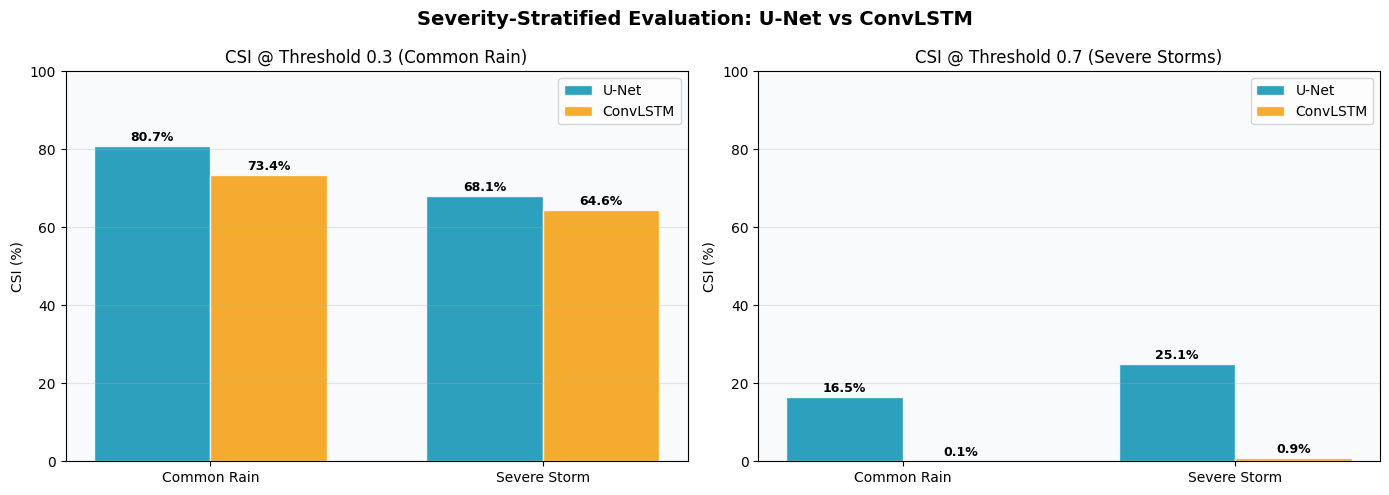

Saved: stratified_evaluation_chart.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Severity-Stratified Evaluation: U-Net vs ConvLSTM", fontsize=14, fontweight='bold')

tiers  = ['Common Rain', 'Severe Storm']
models = ['U-Net', 'ConvLSTM']
colors = {'U-Net': '#0891B2', 'ConvLSTM': '#F59E0B'}
x      = np.arange(len(tiers))
width  = 0.35

for ax, metric_key, title in [
    (axes[0], 'CSI@0.3', 'CSI @ Threshold 0.3 (Common Rain)'),
    (axes[1], 'CSI@0.7', 'CSI @ Threshold 0.7 (Severe Storms)'),
]:
    for j, (model_name, res) in enumerate([('U-Net', unet_results), ('ConvLSTM', clstm_results)]):
        vals = [res.get(tier, {}).get(metric_key, 0) * 100 for tier in tiers]
        bars = ax.bar(x + j * width, vals, width, label=model_name,
                      color=colors[model_name], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=12)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(tiers)
    ax.set_ylabel('CSI (%)')
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#F8FAFC')

plt.tight_layout()
plt.savefig('stratified_evaluation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stratified_evaluation_chart.png")

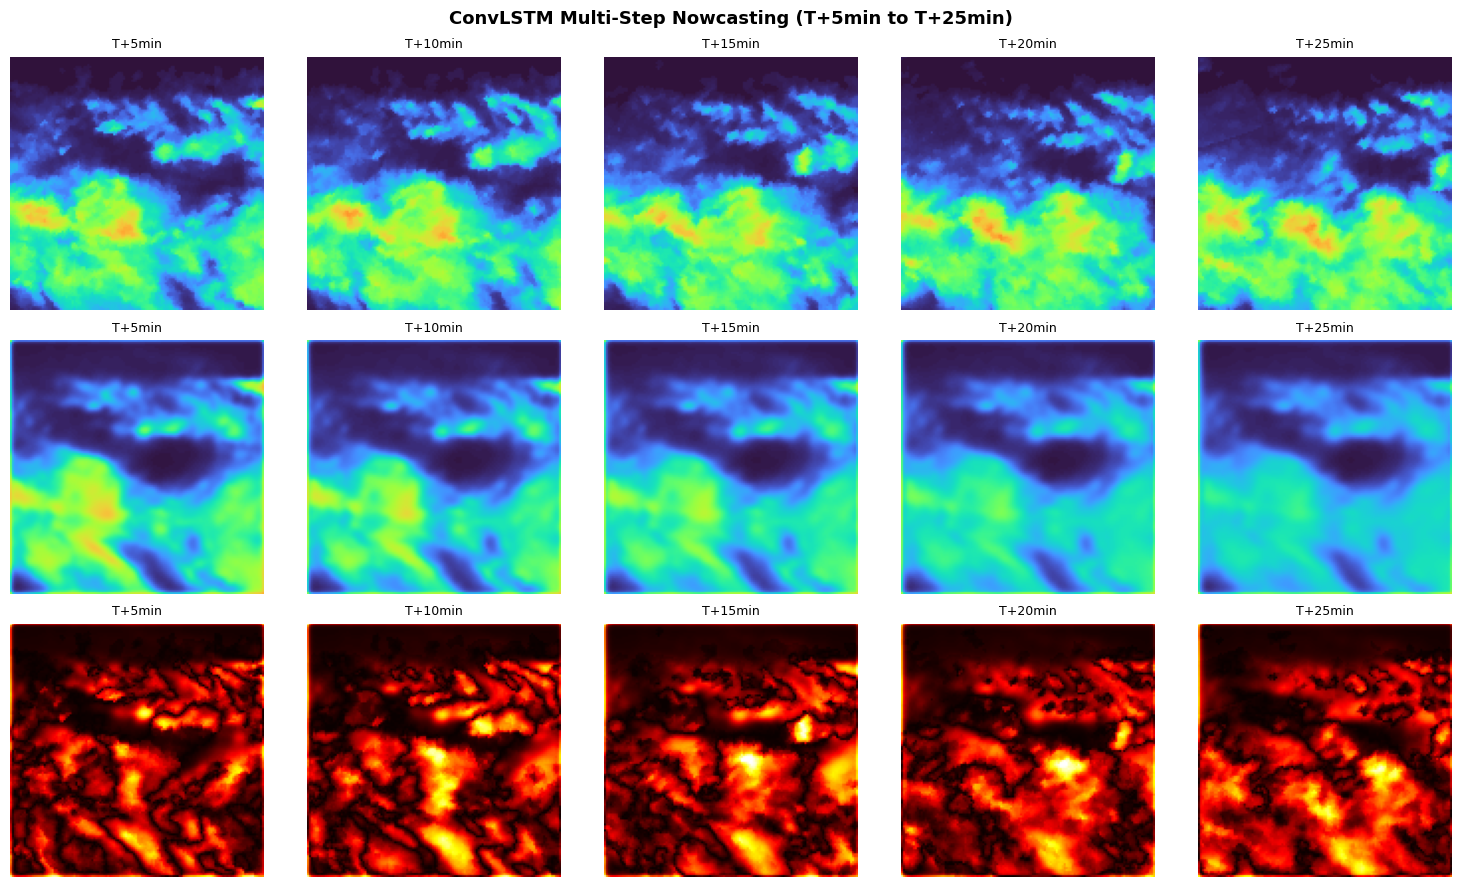

Saved: multistep_predictions.png


In [16]:
model_to_viz = convlstm_model   # swap to unet_model if preferred
model_to_viz.eval()

with torch.no_grad():
    for x_sp, x_sq, y, _ in test_loader:
        inp  = x_sq[:1].to(device)   # single sample
        tgt  = y[:1].to(device)
        pred = model_to_viz(inp)
        break

inp_np  = x_sq[0].squeeze().numpy()   # (T_in, H, W)
tgt_np  = tgt[0].squeeze(1).cpu().numpy()   # (T_out, H, W)
pred_np = pred[0].squeeze(1).cpu().numpy()  # (T_out, H, W)

n_cols = NUM_TARGET
fig, axes = plt.subplots(3, n_cols, figsize=(n_cols * 3, 9))
fig.suptitle("ConvLSTM Multi-Step Nowcasting (T+5min to T+25min)", fontsize=13, fontweight='bold')

row_labels = ['Ground Truth', 'Prediction', 'Error (|GT − Pred|)']
for col in range(n_cols):
    gt   = tgt_np[col]
    pr   = pred_np[col]
    err  = np.abs(gt - pr)

    for row, (data, cmap, vmax) in enumerate([
        (gt,  'turbo', 1.0),
        (pr,  'turbo', 1.0),
        (err, 'hot',   0.5),
    ]):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, vmin=0, vmax=vmax)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=10)
        ax.set_title(f"T+{(col+1)*5}min", fontsize=9)

plt.tight_layout()
plt.savefig('multistep_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multistep_predictions.png")

In [17]:
os.makedirs('saved_models', exist_ok=True)

torch.save(unet_model.state_dict(),     'saved_models/unet_storm_v2.pth')
torch.save(convlstm_model.state_dict(), 'saved_models/convlstm_storm_v2.pth')
print("Both models saved to saved_models/")

# --- To reload later ---
# unet_model.load_state_dict(torch.load('saved_models/unet_storm_v2.pth'))
# convlstm_model.load_state_dict(torch.load('saved_models/convlstm_storm_v2.pth'))

Both models saved to saved_models/
